Preparamos librerías principales (Polars/Pandas para datos, NumPy, Matplotlib/Seaborn) y fijamos un estilo claro para los gráficos.

In [41]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Comprobamos qué archivos hay en la carpeta de trabajo para asegurarnos de que el CSV del Titanic está disponible.

In [42]:
import os

print("Archivos en el directorio actual:", os.listdir('.'))

Archivos en el directorio actual: ['04-ML-Scikit-CuML-Cap-IV.md', '02-ML-Scikit-CuML-Cap-II.html', '01-ML-Scikit-CuML-Cap-I.md', '01-ML-Scikit-CuML-Cap-I.html', 'Tarea', '00-Transicion-EDA-DataPrep-ML.md', 'Actividades', '02-ML-Scikit-CuML-Cap-II.md', '04-ML-Scikit-CuML-Cap-IV.html', '00-ML-Scikit-CuML-Indice.html', '00-ML-Scikit-CuML-Indice.md', '03-ML-Scikit-CuML-Cap-III.md']


In [43]:
# comprobar si estamos en Google Colab
try:
    from google.colab import files
    uploaded = files.upload()   
except ImportError:
    pass

Leemos el CSV del Titanic, mostramos su esquema (tipos y nulos por columna) y las primeras filas para entender la estructura.

In [44]:
# Cargar datos Titanic con Polars
df = pd.read_csv('Actividades/titanic.csv')

# Convertir a Pandas para análisis y visualización

print("\nInformación del dataset:")
df.info()
print("\nPrimeras filas:")
df.head()


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Primeras filas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
# Limpieza e imputación básica antes del análisis
df = df.copy()  # evitar modificar el original en su sitio

# Normalizar cadenas críticas
df['Name'] = df['Name'].fillna('Desconocido').astype(str).str.strip().str.title()
most_common_embarked = df['Embarked'].mode(dropna=True)
default_embarked = most_common_embarked.iloc[0] if not most_common_embarked.empty else 'S'
df['Embarked'] = df['Embarked'].fillna(default_embarked).astype(str).str.strip().str.upper()
df['Sex'] = df['Sex'].fillna('unknown').astype(str).str.strip().str.lower()
df['Cabin'] = df['Cabin'].fillna('').astype(str).str.strip().str.upper()

# Imputar numéricas críticas
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

print('Valores nulos tras la limpieza inicial (deben ser 0 donde se imputó):')
print(df[['Age', 'Fare', 'Embarked']].isnull().sum())


Valores nulos tras la limpieza inicial (deben ser 0 donde se imputó):
Age         0
Fare        0
Embarked    0
dtype: int64


Resumimos nulos, estadísticas básicas y la tasa de supervivencia global para tener una línea base del dataset.

In [4]:
# Valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Estadísticas generales
print("\nEstadísticas del dataset:")
print(df.describe())

# Conteo de supervivientes
print("\nDistribución de supervivencia:")
print(df['Survived'].value_counts())
print(f"\nTasa de supervivencia: {df['Survived'].mean()*100:.2f}%")

Valores nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Estadísticas del dataset:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0

Graficamos la distribución de la variable objetivo `Survived` en barras y contamos cuántos sobrevivieron y cuántos no.

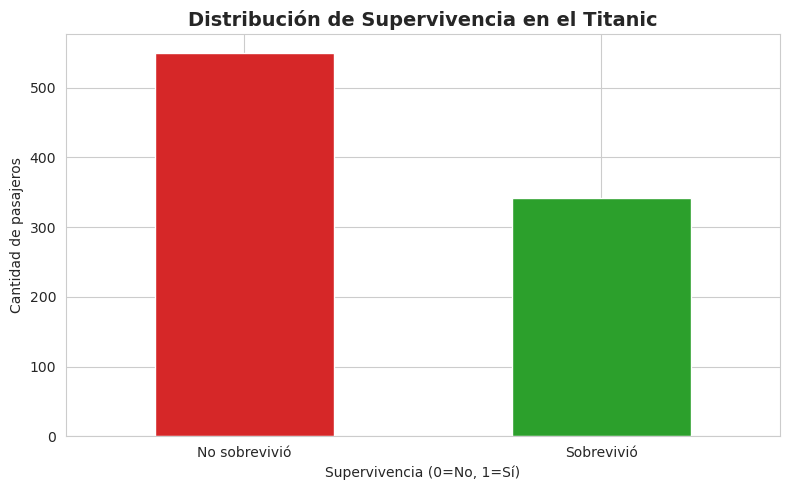

No sobrevivieron: 549 pasajeros
Sobrevivieron: 342 pasajeros


In [5]:
# Gráfico de barras para Survived
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
df['Survived'].value_counts().plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])
ax.set_title('Distribución de Supervivencia en el Titanic', fontsize=14, fontweight='bold')
ax.set_xlabel('Supervivencia (0=No, 1=Sí)')
ax.set_ylabel('Cantidad de pasajeros')
ax.set_xticklabels(['No sobrevivió', 'Sobrevivió'], rotation=0)
plt.tight_layout()
plt.show()

print(f"No sobrevivieron: {(df['Survived']==0).sum()} pasajeros")
print(f"Sobrevivieron: {(df['Survived']==1).sum()} pasajeros")

Vemos cuántos pasajeros son hombres o mujeres y lo mostramos en un gráfico de barras simple.

Distribución por sexo:
Sex
male      577
female    314
Name: count, dtype: int64


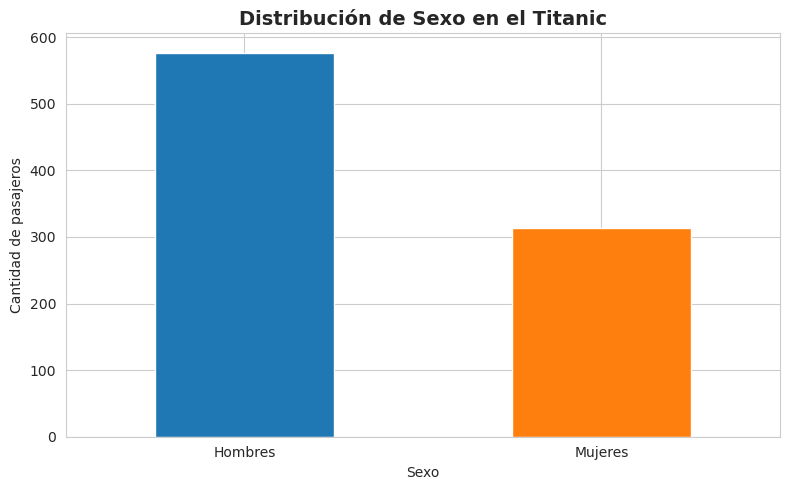

In [6]:
# Distribución por sexo
print("Distribución por sexo:")
print(df['Sex'].value_counts())

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
df['Sex'].value_counts().plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Distribución de Sexo en el Titanic', fontsize=14, fontweight='bold')
ax.set_xlabel('Sexo')
ax.set_ylabel('Cantidad de pasajeros')
ax.set_xticklabels(['Hombres', 'Mujeres'], rotation=0)
plt.tight_layout()
plt.show()

Exploramos la edad: estadísticas básicas y un histograma con líneas de media y mediana para ver su forma.

Estadísticas de Edad:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


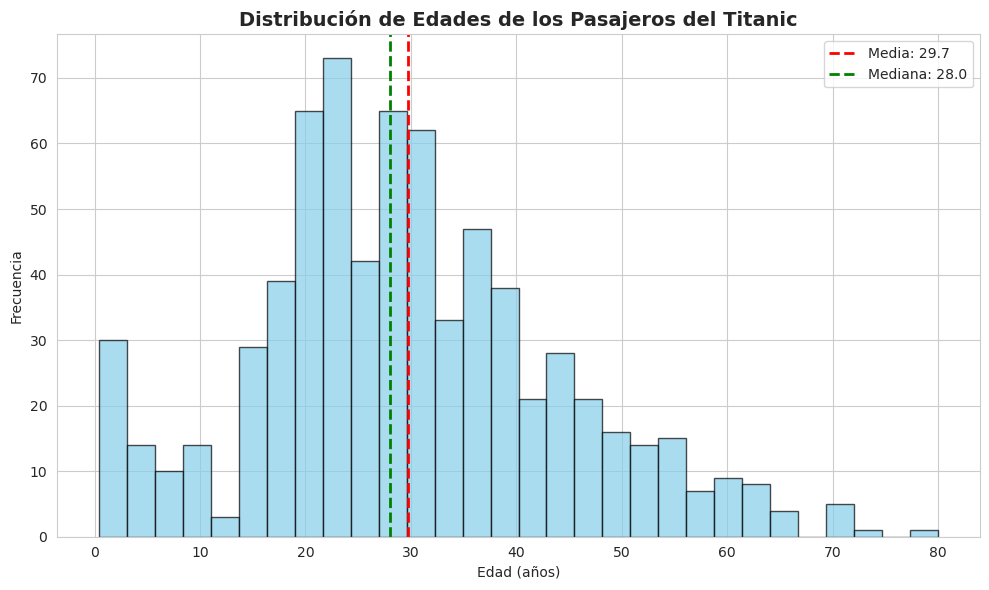

In [7]:
# Estadísticas de edad
print("Estadísticas de Edad:")
print(df['Age'].describe())

# Histograma de edad
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_title('Distribución de Edades de los Pasajeros del Titanic', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Frecuencia')
ax.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f}')
ax.axvline(df['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["Age"].median():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

Exploramos la tarifa (`Fare`) con estadísticas y dos histogramas (escala normal y log) para apreciar mejor los valores extremos.

Estadísticas de Tarifa:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


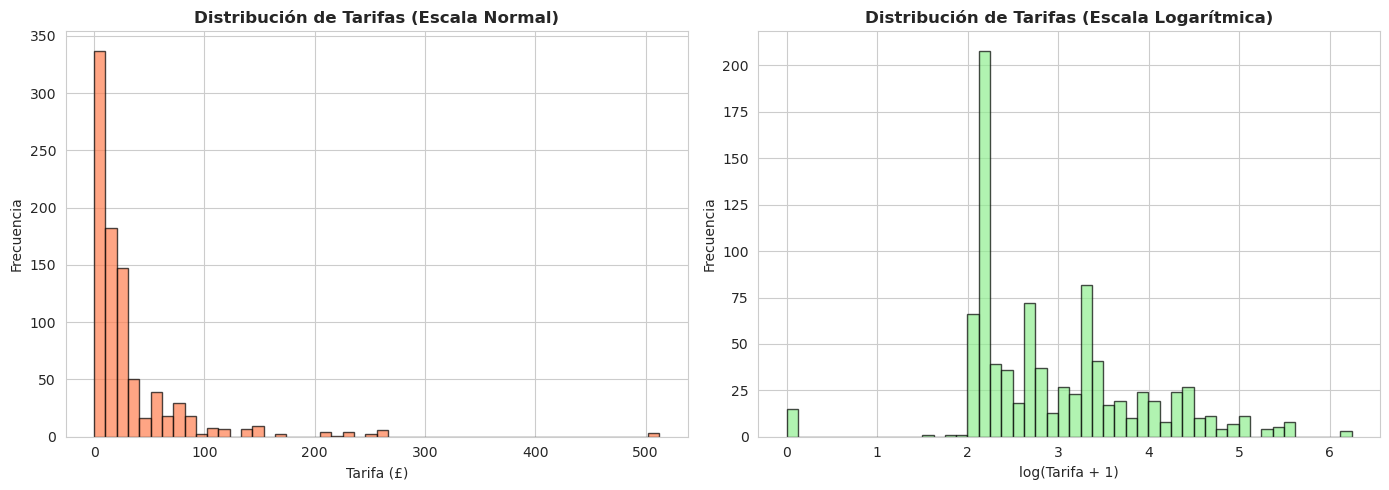


Tarifa máxima: £512.3292
Tarifa mínima: £0.0


In [8]:
# Estadísticas de Fare
print("Estadísticas de Tarifa:")
print(df['Fare'].describe())

# Histograma de Fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala normal
axes[0].hist(df['Fare'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Tarifas (Escala Normal)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tarifa (£)')
axes[0].set_ylabel('Frecuencia')

# Escala logarítmica
axes[1].hist(np.log1p(df['Fare'].dropna()), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de Tarifas (Escala Logarítmica)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Tarifa + 1)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"\nTarifa máxima: £{df['Fare'].max()}")
print(f"Tarifa mínima: £{df['Fare'].min()}")

Contamos los pasajeros por clase (`Pclass`) y lo graficamos, añadiendo porcentajes para cada nivel.

Distribución por Clase de Pasajero:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


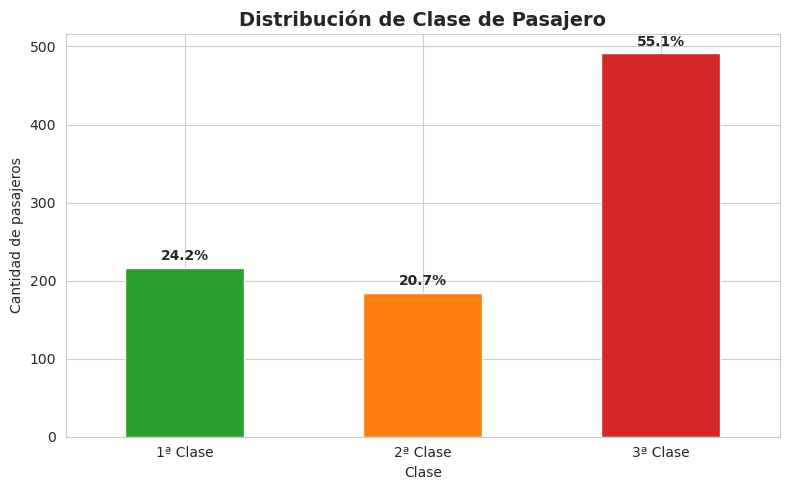

In [9]:
# Distribución por clase
print("Distribución por Clase de Pasajero:")
print(df['Pclass'].value_counts().sort_index())

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#2ca02c', '#ff7f0e', '#d62728'])
ax.set_title('Distribución de Clase de Pasajero', fontsize=14, fontweight='bold')
ax.set_xlabel('Clase')
ax.set_ylabel('Cantidad de pasajeros')
ax.set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'], rotation=0)

# Agregar porcentajes
total = len(df)
for i, v in enumerate(df['Pclass'].value_counts().sort_index()):
    ax.text(i, v + 10, f'{v/total*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Comparamos cuántos familiares acompañaban a cada pasajero (`SibSp` y `Parch`) con dos gráficos de barras y porcentajes base.

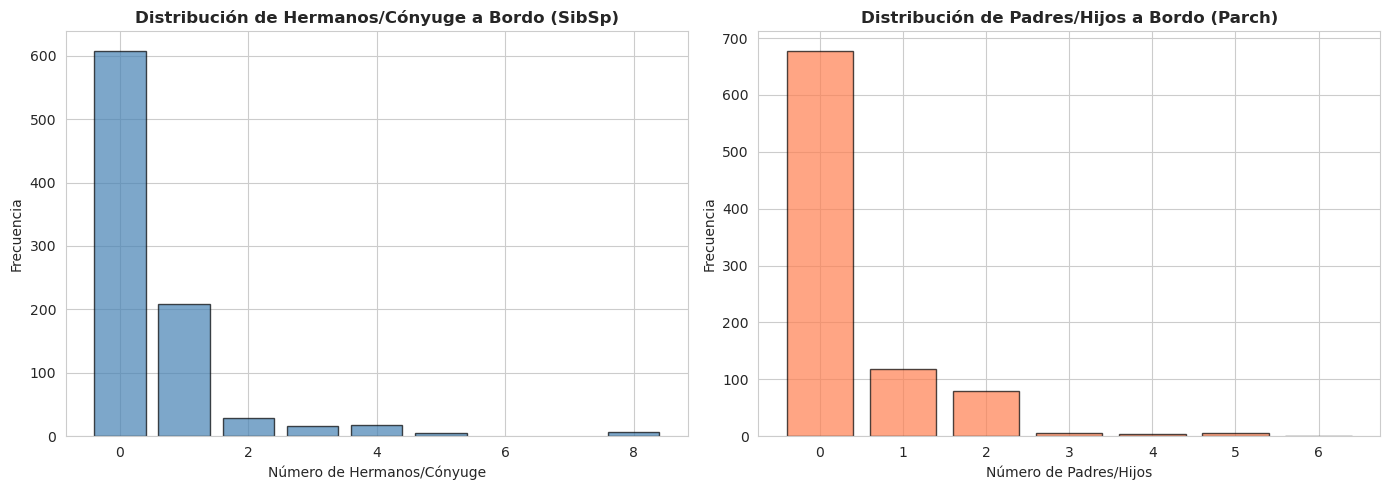

Pasajeros sin hermanos/cónyuge (SibSp=0): 608 (68.2%)
Pasajeros sin padres/hijos (Parch=0): 678 (76.1%)


In [10]:
# Distribución de SibSp y Parch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SibSp
sibsp_counts = df['SibSp'].value_counts().sort_index()
axes[0].bar(sibsp_counts.index, sibsp_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Hermanos/Cónyuge a Bordo (SibSp)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de Hermanos/Cónyuge')
axes[0].set_ylabel('Frecuencia')

# Parch
parch_counts = df['Parch'].value_counts().sort_index()
axes[1].bar(parch_counts.index, parch_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de Padres/Hijos a Bordo (Parch)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Padres/Hijos')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Pasajeros sin hermanos/cónyuge (SibSp=0): {(df['SibSp']==0).sum()} ({(df['SibSp']==0).sum()/len(df)*100:.1f}%)")
print(f"Pasajeros sin padres/hijos (Parch=0): {(df['Parch']==0).sum()} ({(df['Parch']==0).sum()/len(df)*100:.1f}%)")

Revisamos desde qué puerto embarcaron (`Embarked`), mostrando conteos y porcentajes en una sola figura.

Distribución por Puerto de Embarque:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


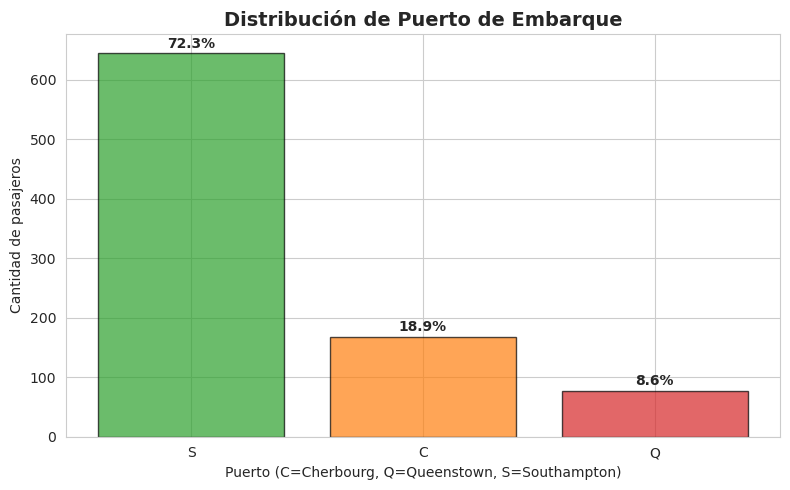

In [11]:
# Distribución por puerto de embarque
print("Distribución por Puerto de Embarque:")
print(df['Embarked'].value_counts())

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
embarked_counts = df['Embarked'].value_counts()
colors = ['#2ca02c', '#ff7f0e', '#d62728']
ax.bar(embarked_counts.index, embarked_counts.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_title('Distribución de Puerto de Embarque', fontsize=14, fontweight='bold')
ax.set_xlabel('Puerto (C=Cherbourg, Q=Queenstown, S=Southampton)')
ax.set_ylabel('Cantidad de pasajeros')

# Agregar porcentajes
total = len(df)
for i, (idx, v) in enumerate(embarked_counts.items()):
    ax.text(i, v + 10, f'{v/total*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis de bivaridado

Analizamos supervivencia según sexo con tablas (conteo y porcentaje) y gráficos apilados y lado a lado.

Supervivencia por Sexo:
Survived    0    1  All
Sex                    
female     81  233  314
male      468  109  577
All       549  342  891

Tasa de Supervivencia por Sexo:
        Sobrevivieron  Total  Tasa de Supervivencia
Sex                                                
female            233    314              74.203822
male              109    577              18.890815


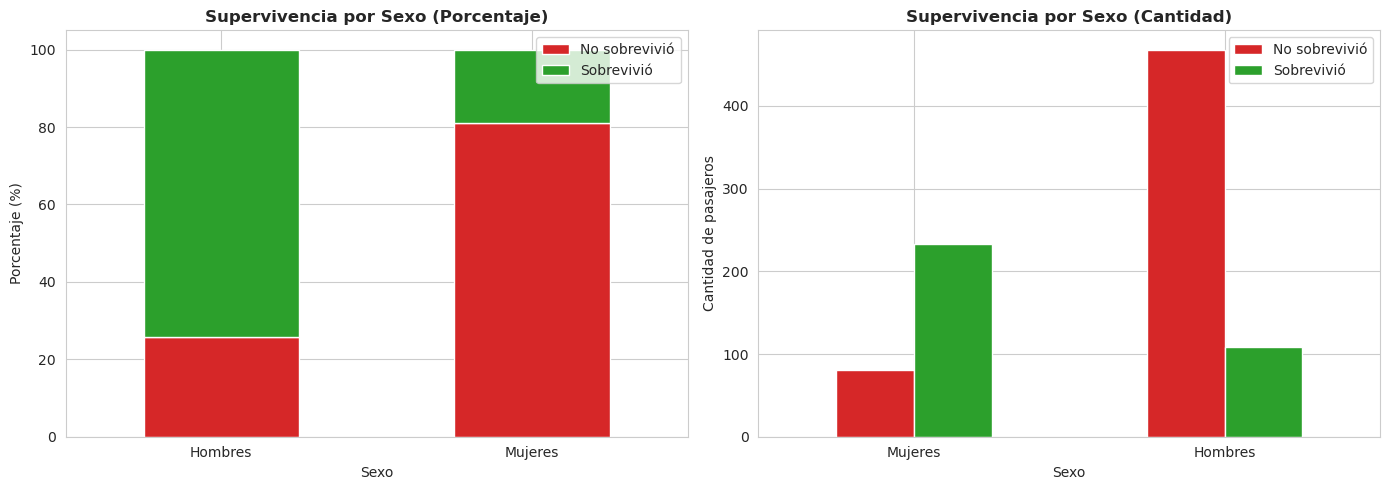

In [12]:
# Supervivencia por sexo
print("Supervivencia por Sexo:")
survival_by_sex = pd.crosstab(df['Sex'], df['Survived'], margins=True)
print(survival_by_sex)

# Tasa de supervivencia por sexo
print("\nTasa de Supervivencia por Sexo:")
survival_rate_sex = df.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean'])
survival_rate_sex.columns = ['Sobrevivieron', 'Total', 'Tasa de Supervivencia']
survival_rate_sex['Tasa de Supervivencia'] = survival_rate_sex['Tasa de Supervivencia'] * 100
print(survival_rate_sex)

# Gráfico de barras apiladas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras apiladas
survival_by_sex_pct = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
survival_by_sex_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#d62728', '#2ca02c'])
axes[0].set_title('Supervivencia por Sexo (Porcentaje)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xticklabels(['Hombres', 'Mujeres'], rotation=0)
axes[0].legend(['No sobrevivió', 'Sobrevivió'], loc='upper right')

# Barras lado a lado
survival_by_sex.iloc[:-1, :-1].plot(kind='bar', ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_title('Supervivencia por Sexo (Cantidad)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Cantidad de pasajeros')
axes[1].set_xticklabels(['Mujeres', 'Hombres'], rotation=0)
axes[1].legend(['No sobrevivió', 'Sobrevivió'], loc='upper right')

plt.tight_layout()
plt.show()

Repetimos el análisis de supervivencia pero por clase, con tablas y gráficos que comparan cantidades y porcentajes.

Supervivencia por Clase:
Survived    0    1  All
Pclass                 
1          80  136  216
2          97   87  184
3         372  119  491
All       549  342  891

Tasa de Supervivencia por Clase:
        Sobrevivieron  Total  Tasa de Supervivencia
Pclass                                             
1                 136    216              62.962963
2                  87    184              47.282609
3                 119    491              24.236253


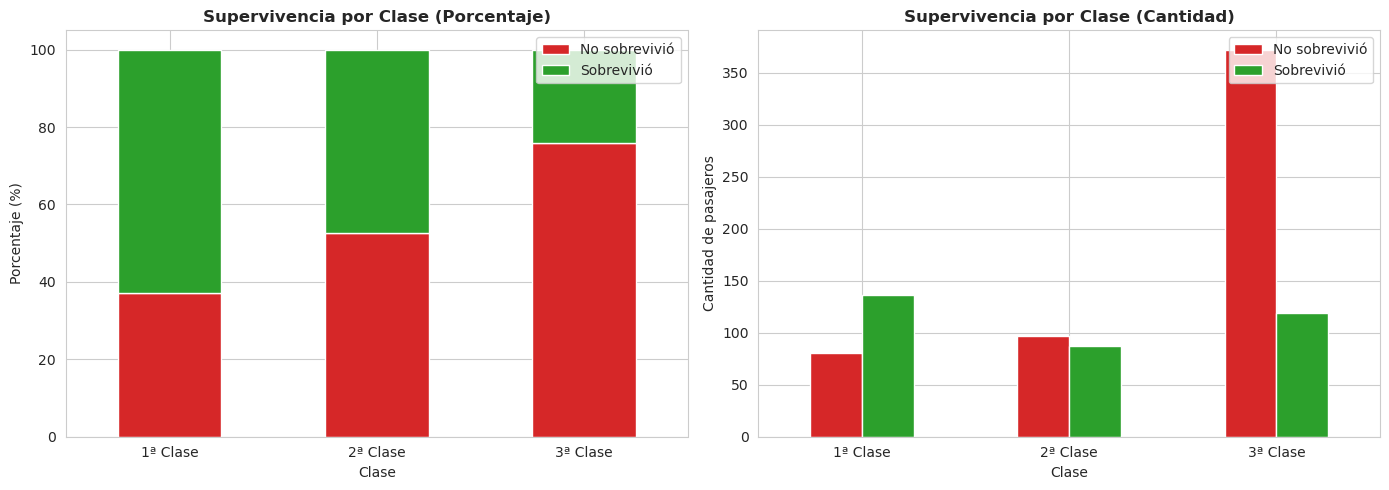

In [13]:
# Supervivencia por clase
print("Supervivencia por Clase:")
survival_by_class = pd.crosstab(df['Pclass'], df['Survived'], margins=True)
print(survival_by_class)

# Tasa de supervivencia por clase
print("\nTasa de Supervivencia por Clase:")
survival_rate_class = df.groupby('Pclass')['Survived'].agg(['sum', 'count', 'mean'])
survival_rate_class.columns = ['Sobrevivieron', 'Total', 'Tasa de Supervivencia']
survival_rate_class['Tasa de Supervivencia'] = survival_rate_class['Tasa de Supervivencia'] * 100
print(survival_rate_class)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras apiladas
survival_by_class_pct = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
survival_by_class_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#d62728', '#2ca02c'])
axes[0].set_title('Supervivencia por Clase (Porcentaje)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'], rotation=0)
axes[0].legend(['No sobrevivió', 'Sobrevivió'], loc='upper right')
# Barras lado a lado
survival_by_class.iloc[:-1, :-1].plot(kind='bar', ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_title('Supervivencia por Clase (Cantidad)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad de pasajeros')
axes[1].set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'], rotation=0)
axes[1].legend(['No sobrevivió', 'Sobrevivió'], loc='upper right')

plt.tight_layout()
plt.show()

Observamos cómo varía la edad según la supervivencia con boxplots y densidades, e investigamos el caso especial de los niños pequeños.

Edad por Supervivencia:
          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


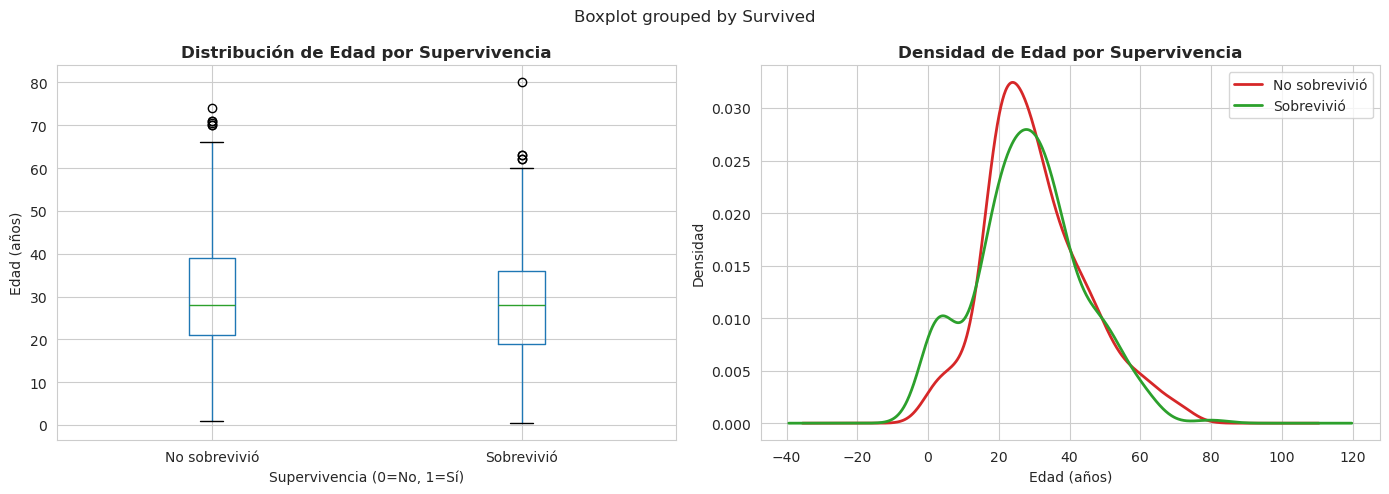


Sobrevivencia de niños menores de 5 años:
Total de niños < 5 años: 40
Sobrevivieron: 27
Tasa de supervivencia: 67.5%


In [14]:
# Estadísticas de edad por supervivencia
print("Edad por Supervivencia:")
print(df.groupby('Survived')['Age'].describe())

# Boxplot de edad por supervivencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='Age', by='Survived', ax=axes[0])
axes[0].set_title('Distribución de Edad por Supervivencia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Supervivencia (0=No, 1=Sí)')
axes[0].set_ylabel('Edad (años)')
plt.sca(axes[0])
plt.xticks([1, 2], ['No sobrevivió', 'Sobrevivió'])

# Gráfico de densidad
df[df['Survived']==0]['Age'].plot(kind='density', ax=axes[1], label='No sobrevivió', linewidth=2, color='#d62728')
df[df['Survived']==1]['Age'].plot(kind='density', ax=axes[1], label='Sobrevivió', linewidth=2, color='#2ca02c')
axes[1].set_title('Densidad de Edad por Supervivencia', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.show()

# Análisis de niños pequeños
print("\nSobrevivencia de niños menores de 5 años:")
children_under_5 = df[df['Age'] < 5]
print(f"Total de niños < 5 años: {len(children_under_5)}")
print(f"Sobrevivieron: {children_under_5['Survived'].sum()}")
print(f"Tasa de supervivencia: {children_under_5['Survived'].mean()*100:.1f}%")

Hacemos lo mismo con la tarifa: tablas, boxplots y densidad logarítmica para ver diferencias entre quienes sobrevivieron y quienes no.

Tarifa por Supervivencia:
          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292

Tarifa Promedio por Supervivencia:
                    mean  median  count
No sobrevivió  22.117887    10.5    549
Sobrevivió     48.395408    26.0    342


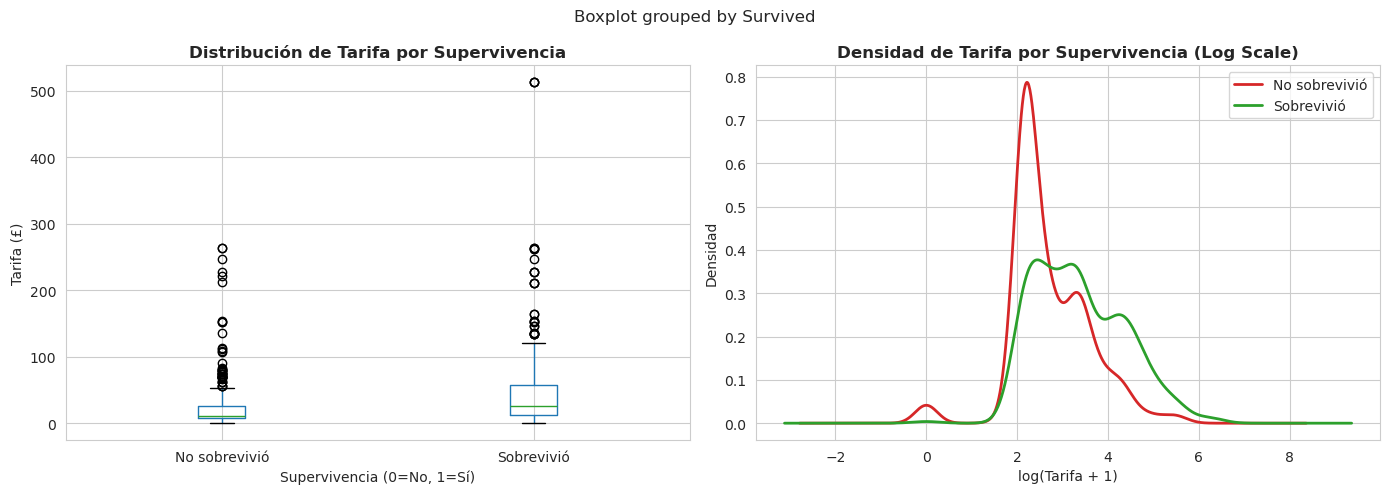

In [15]:
# Estadísticas de tarifa por supervivencia
print("Tarifa por Supervivencia:")
print(df.groupby('Survived')['Fare'].describe())

# Tarifa promedio por supervivencia
print("\nTarifa Promedio por Supervivencia:")
fare_by_survival = df.groupby('Survived')['Fare'].agg(['mean', 'median', 'count'])
fare_by_survival.index = ['No sobrevivió', 'Sobrevivió']
print(fare_by_survival)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='Fare', by='Survived', ax=axes[0])
axes[0].set_title('Distribución de Tarifa por Supervivencia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Supervivencia (0=No, 1=Sí)')
axes[0].set_ylabel('Tarifa (£)')
plt.sca(axes[0])
plt.xticks([1, 2], ['No sobrevivió', 'Sobrevivió'])

# Gráfico de densidad (escala logarítmica)
df[df['Survived']==0]['Fare'].apply(lambda x: np.log1p(x)).plot(kind='density', ax=axes[1], 
                                                                   label='No sobrevivió', linewidth=2, color='#d62728')
df[df['Survived']==1]['Fare'].apply(lambda x: np.log1p(x)).plot(kind='density', ax=axes[1], 
                                                                   label='Sobrevivió', linewidth=2, color='#2ca02c')
axes[1].set_title('Densidad de Tarifa por Supervivencia (Log Scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Tarifa + 1)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.show()

Creamos el tamaño de familia (`FamilySize`), calculamos su tasa de supervivencia y la cantidad de pasajeros por cada tamaño, con dos gráficos.

Supervivencia por Tamaño de Familia:
            Sobrevivieron  Total  Tasa de Supervivencia
FamilySize                                             
1                     163    537              30.353818
2                      89    161              55.279503
3                      59    102              57.843137
4                      21     29              72.413793
5                       3     15              20.000000
6                       3     22              13.636364
7                       4     12              33.333333
8                       0      6               0.000000
11                      0      7               0.000000


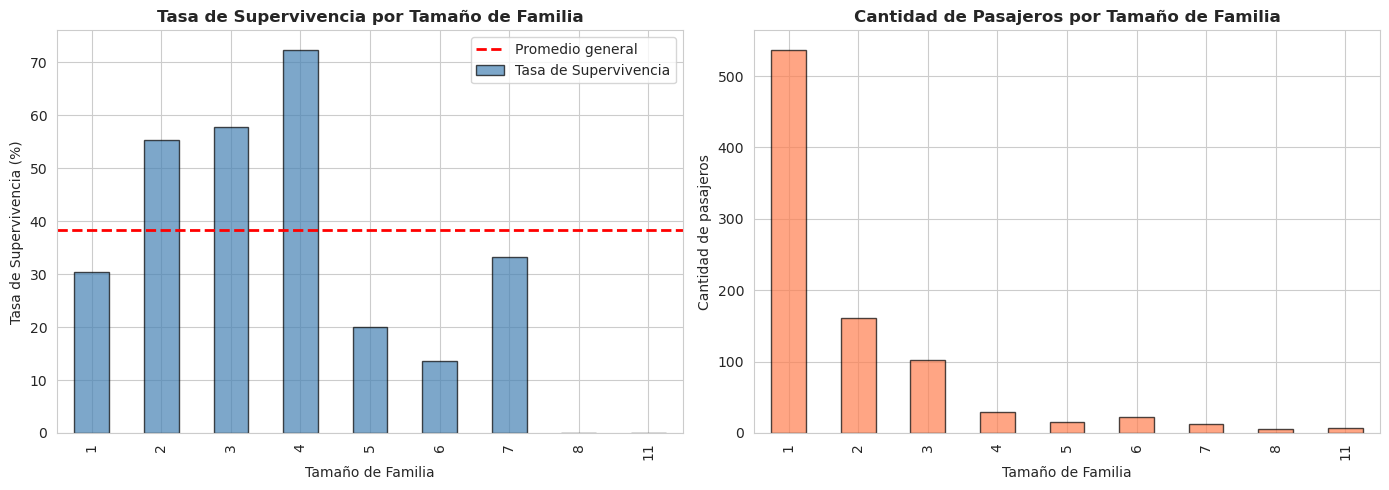

In [47]:
# Crear variable FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Supervivencia por tamaño de familia
print("Supervivencia por Tamaño de Familia:")
survival_by_family = df.groupby('FamilySize')['Survived'].agg(['sum', 'count', 'mean'])
survival_by_family.columns = ['Sobrevivieron', 'Total', 'Tasa de Supervivencia']
survival_by_family['Tasa de Supervivencia'] = survival_by_family['Tasa de Supervivencia'] * 100
print(survival_by_family)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de tasa de supervivencia
survival_by_family['Tasa de Supervivencia'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Tasa de Supervivencia por Tamaño de Familia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tamaño de Familia')
axes[0].set_ylabel('Tasa de Supervivencia (%)')
axes[0].axhline(y=df['Survived'].mean()*100, color='red', linestyle='--', linewidth=2, label='Promedio general')
axes[0].legend()
# Cantidad de pasajeros por tamaño de familia
survival_by_family['Total'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Cantidad de Pasajeros por Tamaño de Familia', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tamaño de Familia')
axes[1].set_ylabel('Cantidad de pasajeros')

plt.tight_layout()
plt.show()

Estudiamos supervivencia según puerto de embarque y comparamos también la mezcla de clases dentro de cada puerto.

Supervivencia por Puerto de Embarque:
Survived    0    1  All
Embarked               
C          75   93  168
Q          47   30   77
S         427  217  644
All       549  340  889

Tasa de Supervivencia por Puerto:
          Sobrevivieron  Total  Tasa de Supervivencia
Embarked                                             
C                    93    168              55.357143
Q                    30     77              38.961039
S                   217    644              33.695652


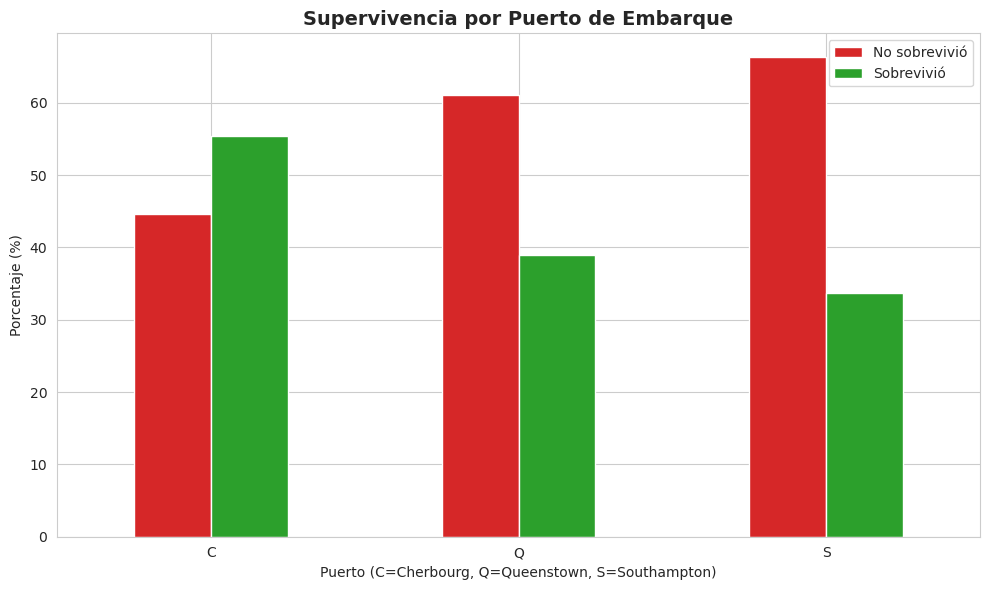


Distribución de Clase por Puerto:
Pclass            1          2          3
Embarked                                 
C         50.595238  10.119048  39.285714
Q          2.597403   3.896104  93.506494
S         19.720497  25.465839  54.813665


In [17]:
# Supervivencia por puerto
print("Supervivencia por Puerto de Embarque:")
survival_by_embarked = pd.crosstab(df['Embarked'], df['Survived'], margins=True)
print(survival_by_embarked)

# Tasa de supervivencia por puerto
print("\nTasa de Supervivencia por Puerto:")
survival_rate_embarked = df.groupby('Embarked')['Survived'].agg(['sum', 'count', 'mean'])
survival_rate_embarked.columns = ['Sobrevivieron', 'Total', 'Tasa de Supervivencia']
survival_rate_embarked['Tasa de Supervivencia'] = survival_rate_embarked['Tasa de Supervivencia'] * 100
print(survival_rate_embarked)

# Gráfico
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
survival_by_embarked_pct = pd.crosstab(df['Embarked'], df['Survived'], normalize='index') * 100
survival_by_embarked_pct.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'])
ax.set_title('Supervivencia por Puerto de Embarque', fontsize=14, fontweight='bold')
ax.set_xlabel('Puerto (C=Cherbourg, Q=Queenstown, S=Southampton)')
ax.set_ylabel('Porcentaje (%)')
ax.set_xticklabels(['C', 'Q', 'S'], rotation=0)
ax.legend(['No sobrevivió', 'Sobrevivió'], loc='upper right')

plt.tight_layout()
plt.show()

# Relación con clase
print("\nDistribución de Clase por Puerto:")
print(pd.crosstab(df['Embarked'], df['Pclass'], normalize='index') * 100)

Calculamos la matriz de correlación de las variables numéricas y la mostramos como heatmap para detectar relaciones lineales.

Matriz de Correlación:
            Survived    Pclass       Age     SibSp     Parch      Fare  \
Survived    1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307   
Pclass     -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500   
Age        -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067   
SibSp      -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651   
Parch       0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225   
Fare        0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000   
FamilySize  0.016639  0.065997 -0.301914  0.890712  0.783111  0.217138   

            FamilySize  
Survived      0.016639  
Pclass        0.065997  
Age          -0.301914  
SibSp         0.890712  
Parch         0.783111  
Fare          0.217138  
FamilySize    1.000000  


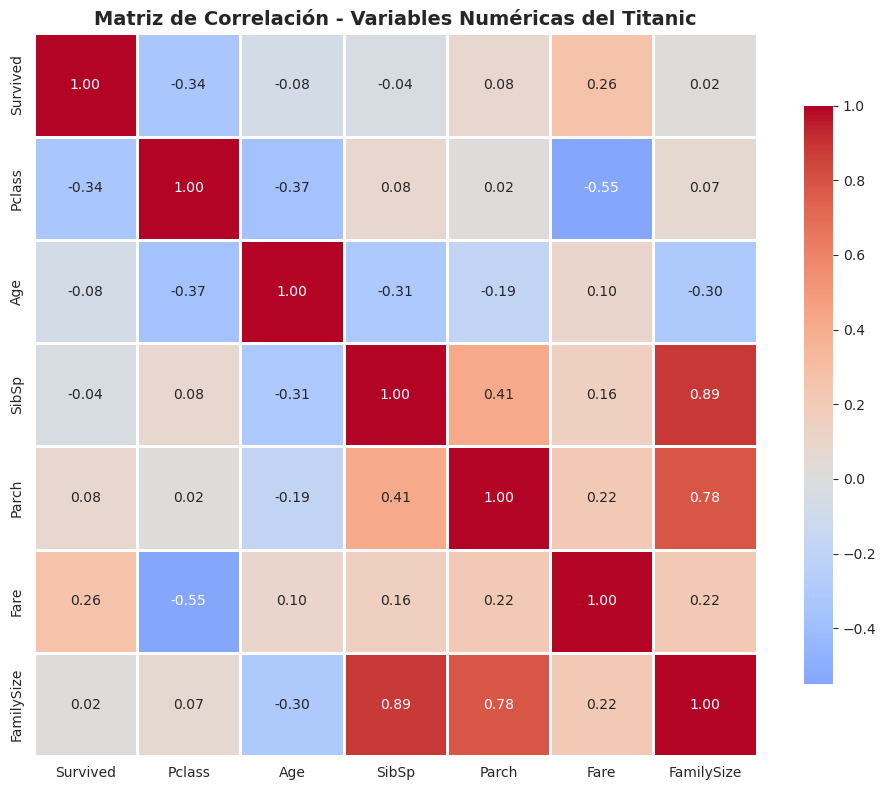


Correlaciones con Survived (ordenadas):
Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.077221
Pclass       -0.338481
Name: Survived, dtype: float64


In [20]:
# Seleccionar variables numéricas
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
df_numeric = df[numeric_cols].copy()

# Calcular matriz de correlación
correlation_matrix = df_numeric.corr()

print("Matriz de Correlación:")
print(correlation_matrix)

# Heatmap de correlación
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlación - Variables Numéricas del Titanic', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Correlaciones más importantes con Survived
print("\nCorrelaciones con Survived (ordenadas):")
print(correlation_matrix['Survived'].sort_values(ascending=False))

# Medidas de asociación para variables categóricas y mixtas

Para variables categóricas la correlación de Pearson no aplica (necesita números con escala y linealidad). En vez de la típica "correlación", usamos medidas que comparan cómo se reparten las frecuencias y cuánta sorpresa se reduce al saber otra variable.

- **Entropía H(X)**: mide la "sorpresa" promedio. Si todo es impredecible, la entropía es alta; si todo es seguro, es 0. Fórmula: $H(X) = -\sum p(x) \log_2 p(x)$.
- **Información mutua MI(X,Y)**: cuánta sorpresa se reduce al conocer la otra variable. Es $MI(X,Y) = H(X) + H(Y) - H(X,Y)$; vale 0 si son independientes.
- **Chi-cuadrado (χ²)**: compara frecuencias observadas vs. esperadas si no hubiera relación: $\chi^2 = \sum\frac{(O - E)^2}{E}$. Si χ² es alto, hay evidencia de dependencia. Es la base para Cramér's V.
- **Cramér's V**: fuerza de asociación para dos categóricas en cualquier tabla, derivada de χ²: $V = \sqrt{\frac{\chi^2 / n}{\min(k-1,\, r-1)}}$. Rango 0..1 (0 sin relación, 1 relación fuerte).
- **Phi (φ)**: versión de correlación para tablas 2x2: $\phi = \frac{ad - bc}{\sqrt{(a+b)(c+d)(a+c)(b+d)}}$. Rango -1..1; en 2x2, |φ| = V.
- **Theil's U U(Y|X)**: porcentaje de incertidumbre (entropía) de Y que se reduce al saber X. Va de 0 (no ayuda) a 1 (X predice perfecto). Es asimétrica: U(Y|X) no tiene por qué ser igual a U(X|Y).
- **Correlación ratio η (eta)**: para numérica ↔ categórica. Compara varianza entre grupos vs. total: $\eta = \sqrt{SS_{between} / SS_{total}}$. Va de 0..1 y captura diferencias de medias entre categorías.

Idea/analogía: entropía es la cantidad de "misterio"; la información mutua mide cuánto misterio se disipa al saber otra variable. Chi-cuadrado y Cramér's V miden cuánto se desvían las frecuencias de lo que esperaríamos si no hubiera relación. Phi es la versión 2x2. Theil's U dice qué porcentaje de incertidumbre desaparece al conocer X. Eta pregunta si las medias por grupo son distintas.

Abajo se definen funciones para estas medidas y se muestran ejemplos con `Sex`↔`Survived` y una matriz mixta para el resto.


Definimos funciones de asociación: Cramér's V (fuerza de relación entre dos categorías), phi para tablas 2x2, Theil's U (cuánta incertidumbre se reduce al conocer otra variable) y eta para comparar categorías con números. Sirve para ver dependencia sin modelos complicados.

In [21]:
# Funciones de asociación para categóricas y mixtas
import numpy as np
import pandas as pd

# Cramér's V (con corrección por sesgo)
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    n = ct.values.sum()
    if n == 0:
        return 0.0
    row_sums = ct.sum(axis=1).values.reshape(-1, 1)
    col_sums = ct.sum(axis=0).values.reshape(1, -1)
    expected = row_sums @ col_sums / n
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2 = np.nansum((ct.values - expected) ** 2 / expected)
    phi2 = chi2 / n
    r, k = ct.shape
    if n <= 1:
        return 0.0
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return 0.0
    return float(np.sqrt(phi2corr / denom))

# Phi para tablas 2x2
def phi_coef(x, y):
    ct = pd.crosstab(x, y)
    if ct.shape != (2, 2):
        raise ValueError("Phi está definido solo para tablas 2x2.")
    a, b, c, d = ct.values[0, 0], ct.values[0, 1], ct.values[1, 0], ct.values[1, 1]
    denom = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
    if denom == 0:
        return 0.0
    return float((a * d - b * c) / denom)

# Theil's U: U(Y|X) reducción de incertidumbre de Y dado X
def theils_u(x, y):
    ct = pd.crosstab(x, y)
    n = ct.values.sum()
    if n == 0:
        return 0.0
    p_xy = ct / n
    p_x = p_xy.sum(axis=1)
    p_y = p_xy.sum(axis=0)

    def H(p):
        p = p.values if hasattr(p, 'values') else np.asarray(p)
        p = p[p > 0]
        return -np.sum(p * np.log2(p)) if p.size else 0.0

    H_y = H(p_y)
    if H_y == 0:
        return 0.0
    H_y_given_x = 0.0
    for xi in p_x.index:
        if p_x.loc[xi] == 0:
            continue
        p_y_given_x = p_xy.loc[xi] / p_x.loc[xi]
        H_y_given_x += p_x.loc[xi] * H(p_y_given_x)
    return float((H_y - H_y_given_x) / H_y)

# Correlation ratio (eta): numérica (y) vs categórica (x)
def correlation_ratio(x, y):
    x = pd.Series(x)
    y = pd.Series(y, dtype=float)
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    if y.size == 0 or y.var() == 0:
        return 0.0
    overall_mean = y.mean()
    ss_between = 0.0
    for cat in x.unique():
        vals = y[x == cat]
        if vals.size:
            ss_between += vals.size * (vals.mean() - overall_mean) ** 2
    ss_total = np.sum((y - overall_mean) ** 2)
    if ss_total == 0:
        return 0.0
    return float(np.sqrt(ss_between / ss_total))

# Matriz de asociación mixta: Pearson (num-num), Cramér's V (cat-cat), eta (mixta)
def association_matrix(df, num_cols, cat_cols):
    cols = list(dict.fromkeys(list(num_cols) + list(cat_cols)))
    mat = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols, dtype=float)
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if j < i:
                continue
            if c1 in num_cols and c2 in num_cols:
                val = df[[c1, c2]].corr(method='pearson').iloc[0, 1]
            elif c1 in cat_cols and c2 in cat_cols:
                val = cramers_v(df[c1], df[c2])
            elif c1 in cat_cols and c2 in num_cols:
                val = correlation_ratio(df[c1], df[c2])
            elif c1 in num_cols and c2 in cat_cols:
                val = correlation_ratio(df[c2], df[c1])
            else:
                val = np.nan
            mat.loc[c1, c2] = val
            mat.loc[c2, c1] = val
    return mat

Aplicamos esas medidas a `Sex` vs `Survived`: Cramér's V (0=sin relación, 1=muy fuerte), Phi si la tabla es 2x2, Theil's U para ver cuánta información aporta una variable sobre la otra y eta para ver diferencias en edad/tarifa por sexo.

In [22]:
# Asociación específica: Sex ↔ Survived
print("Asociación entre Sex y Survived:")
cv = cramers_v(df['Sex'], df['Survived'])
print(f"  Cramér's V: {cv:.3f} (0..1)")

# Phi solo si es 2x2
if df['Sex'].nunique(dropna=True) == 2 and df['Survived'].nunique(dropna=True) == 2:
    try:
        phi = phi_coef(df['Sex'], df['Survived'])
        print(f"  Phi (2x2): {phi:.3f} (-1..1)")
    except Exception as e:
        print(f"  Phi no disponible: {e}")

# Theil's U (asimétrica)
uyx = theils_u(df['Sex'], df['Survived'])     # U(Survived | Sex)
uxy = theils_u(df['Survived'], df['Sex'])     # U(Sex | Survived)
print(f"  Theil's U U(Survived|Sex): {uyx:.3f}")
print(f"  Theil's U U(Sex|Survived): {uxy:.3f}")

# Ejemplos de mixta: diferencias por sexo en variables numéricas
eta_age = correlation_ratio(df['Sex'], df['Age'])
eta_fare = correlation_ratio(df['Sex'], df['Fare'])
print(f"\nEta (Age|Sex): {eta_age:.3f}  |  Eta (Fare|Sex): {eta_fare:.3f}")

Asociación entre Sex y Survived:
  Cramér's V: 0.543 (0..1)
  Phi (2x2): -0.543 (-1..1)
  Theil's U U(Survived|Sex): 0.227
  Theil's U U(Sex|Survived): 0.232

Eta (Age|Sex): 0.093  |  Eta (Fare|Sex): 0.182


Construimos una matriz mixta con todas las variables: correlación de Pearson para numéricas, Cramér's V para categóricas y eta para combinaciones mixtas, y la visualizamos en un heatmap.

Matriz de asociación (valores en [-1,1] donde aplica):
            Survived    Pclass       Age     SibSp     Parch      Fare  \
Survived    1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307   
Pclass     -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500   
Age        -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067   
SibSp      -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651   
Parch       0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225   
Fare        0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000   
FamilySize  0.016639  0.065997 -0.301914  0.890712  0.783111  0.217138   
Sex         0.543351  0.131900  0.093254  0.114631  0.245489  0.182333   
Embarked    0.172617  0.308249  0.042340  0.070046  0.085037  0.281550   

            FamilySize       Sex  Embarked  
Survived      0.016639  0.543351  0.172617  
Pclass        0.065997  0.131900  0.308249  
Age          -0.301914  0.093254  0.042340  
SibSp         0.890712  

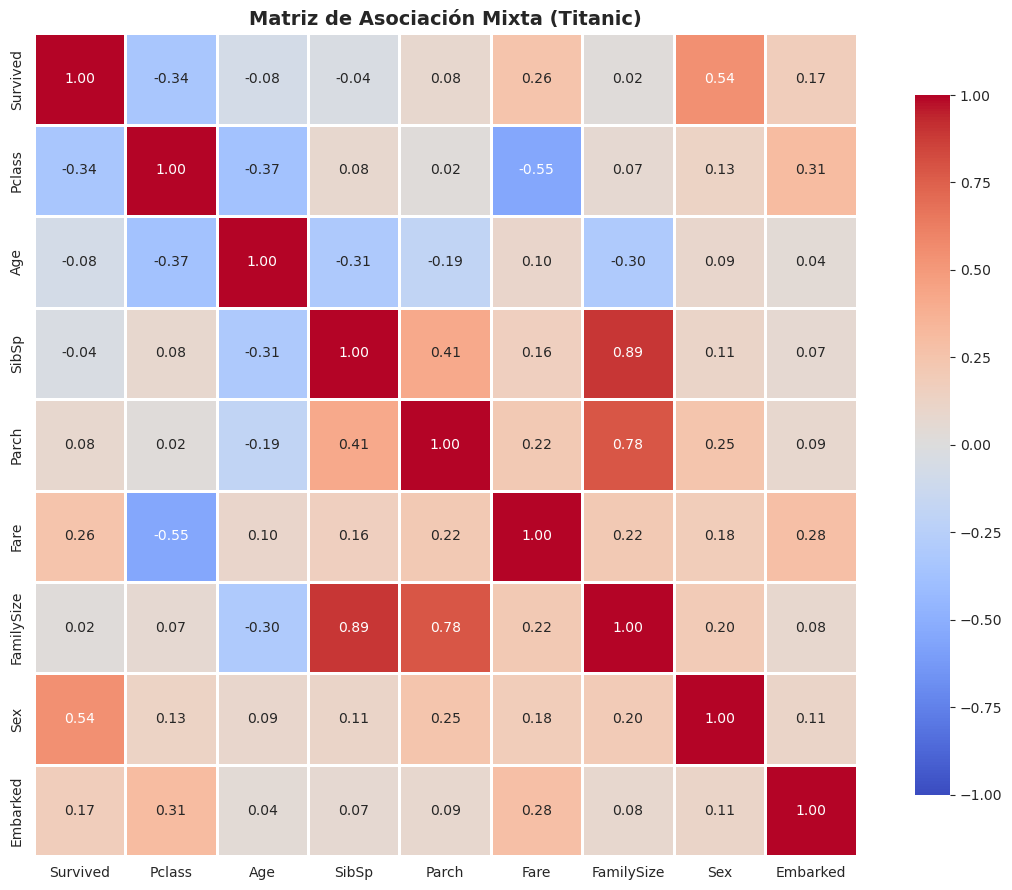

In [23]:
# Matriz de asociación mixta (num-num: Pearson; cat-cat: Cramér's V; mixta: eta)
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
cat_cols = ['Sex', 'Embarked']

assoc = association_matrix(df, num_cols=num_cols, cat_cols=cat_cols)
print("Matriz de asociación (valores en [-1,1] donde aplica):")
print(assoc)

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
sns.heatmap(assoc, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=1, cbar_kws={"shrink": 0.85}, ax=ax)
ax.set_title('Matriz de Asociación Mixta (Titanic)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mutual Information con scikit-learn

`scikit-learn` ofrece medidas de información mutua específicas para tareas:

- `mutual_info_classif(X, y)`: relevancia de las variables respecto a un objetivo de clasificación.
- `mutual_info_regression(X, y)`: relevancia respecto a un objetivo continuo (regresión).

Notas prácticas:
- Admite mezcla de variables continuas y discretas vía `discrete_features` (boolean mask o índices).
- No acepta nulos: conviene limpiar o imputar antes.
- El valor no está normalizado (≥ 0) y no es comparable en términos absolutos entre datasets; úsalo para ranking.
- `mutual_info_score` opera sobre una única pareja de vectores categóricos; para conjuntos de features usa las funciones anteriores.

Calculamos Información Mutua respecto a `Survived`: preparamos datos, codificamos categorías a números y medimos qué tan útil es cada feature para predecir la supervivencia.

Información mutua respecto a Survived (mayor ⇒ más informativa):
Sex_code         0.148409
Fare             0.136918
Pclass           0.065163
FamilySize       0.045642
Age              0.025869
Parch            0.021267
Embarked_code    0.019310
SibSp            0.017238
dtype: float64


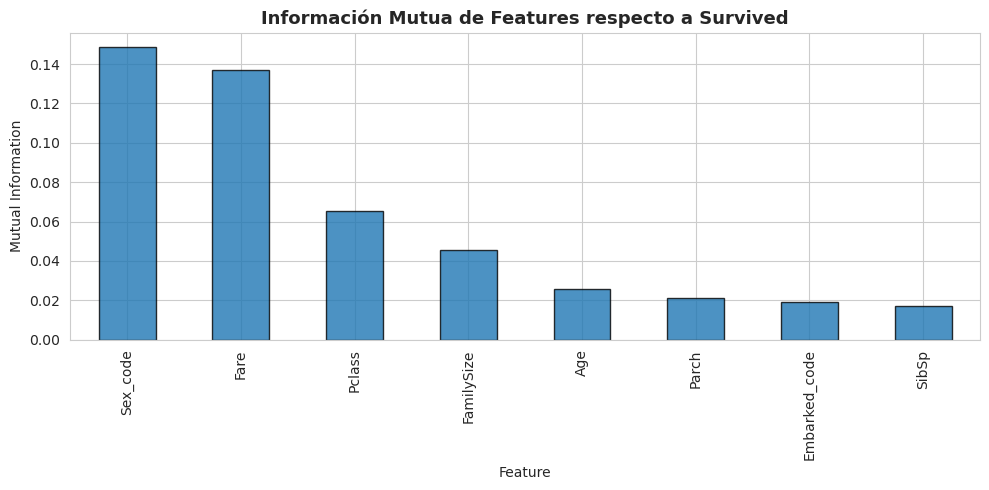

In [24]:
# Información mutua (clasificación): relevancia de features respecto a Survived
try:
    from sklearn.feature_selection import mutual_info_classif
except Exception as e:
    print("scikit-learn no está disponible. Instálalo con: pip install scikit-learn")
    raise

# Selección de columnas y limpieza de nulos
features_num = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
features_cat = ['Sex', 'Embarked']
cols_needed = ['Survived'] + features_num + features_cat

df_mi = df[cols_needed].dropna().copy()

# Codificar categóricas a enteros (factorize mantiene orden estable)
for c in features_cat:
    df_mi[c + '_code'], _ = pd.factorize(df_mi[c], sort=True)

X_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Sex_code', 'Embarked_code']
X = df_mi[X_cols].to_numpy()
y = df_mi['Survived'].to_numpy()

# Marcar variables discretas (True) vs continuas (False)
# Consideramos discretas: Pclass, SibSp, Parch, FamilySize, Sex_code, Embarked_code
discrete_mask = [True,  False, True,  True,  False,       True,       True,       True]

mi = mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=0)
mi_series = pd.Series(mi, index=X_cols).sort_values(ascending=False)

print("Información mutua respecto a Survived (mayor ⇒ más informativa):")
print(mi_series)

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
mi_series.plot(kind='bar', ax=ax, color='#1f77b4', edgecolor='black', alpha=0.8)
ax.set_title('Información Mutua de Features respecto a Survived', fontsize=13, fontweight='bold')
ax.set_ylabel('Mutual Information')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

Como ejemplo de regresión, medimos la Información Mutua respecto a `Fare` para ver qué variables ayudan a explicar la tarifa pagada.

Información mutua respecto a Fare (regresión):
Pclass           0.856859
FamilySize       0.635086
SibSp            0.349365
Embarked_code    0.301975
Parch            0.274769
Age              0.104806
Sex_code         0.074929
dtype: float64


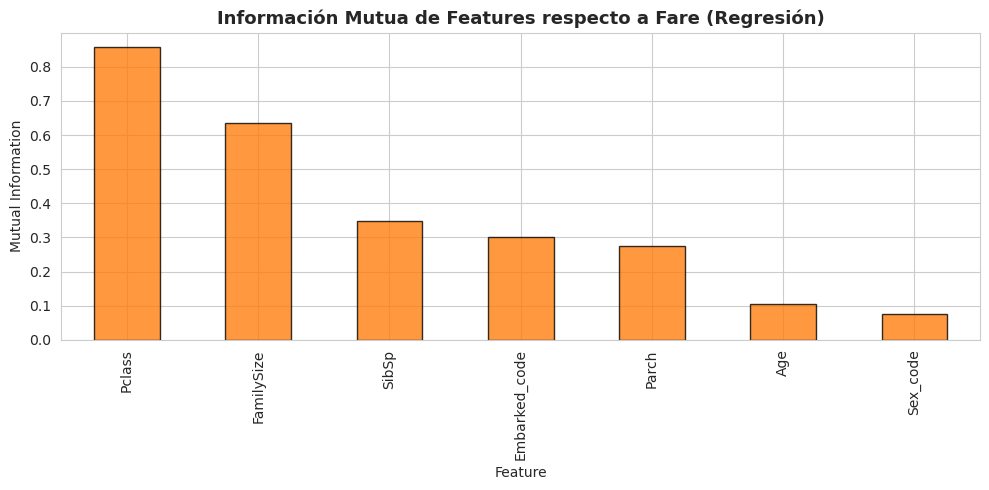

In [25]:
# (Opcional) Información mutua para regresión: ejemplo con y=Fare
try:
    from sklearn.feature_selection import mutual_info_regression
except Exception as e:
    print("scikit-learn no está disponible. Instálalo con: pip install scikit-learn")
    raise

# Usamos mismas features (sin incluir Fare en X si es el objetivo)
features_num_reg = ['Pclass', 'Age', 'SibSp', 'Parch', 'FamilySize']
features_cat_reg = ['Sex', 'Embarked']
cols_needed_reg = ['Fare'] + features_num_reg + features_cat_reg

df_mi_reg = df[cols_needed_reg].dropna().copy()
for c in features_cat_reg:
    df_mi_reg[c + '_code'], _ = pd.factorize(df_mi_reg[c], sort=True)

X_cols_reg = ['Pclass', 'Age', 'SibSp', 'Parch', 'FamilySize', 'Sex_code', 'Embarked_code']
X_reg = df_mi_reg[X_cols_reg].to_numpy()
y_reg = df_mi_reg['Fare'].to_numpy()

# Discretas vs continuas para regresión (similar a antes)
discrete_mask_reg = [True, False, True, True, True, True, True]

mi_reg = mutual_info_regression(X_reg, y_reg, discrete_features=discrete_mask_reg, random_state=0)
mi_reg_series = pd.Series(mi_reg, index=X_cols_reg).sort_values(ascending=False)

print("Información mutua respecto a Fare (regresión):")
print(mi_reg_series)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
mi_reg_series.plot(kind='bar', ax=ax, color='#ff7f0e', edgecolor='black', alpha=0.8)
ax.set_title('Información Mutua de Features respecto a Fare (Regresión)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mutual Information')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

Preparamos una versión con imputación simple: medianas para números y valores más frecuentes para categorías, y codificamos las variables categóricas.

In [ ]:
# Imputación simple para MI: medianas (num) y modas (cat)
from sklearn.impute import SimpleImputer

features_num = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
features_cat = ['Sex', 'Embarked']
cols_needed = ['Survived'] + features_num + features_cat

df_mi2 = df[cols_needed].copy()

# Separar numéricas y categóricas
num_imp = SimpleImputer(strategy='median')
cat_imp = SimpleImputer(strategy='most_frequent')

# Imputar numéricas
df_mi2[features_num] = num_imp.fit_transform(df_mi2[features_num])
# Imputar categóricas
df_mi2[features_cat] = cat_imp.fit_transform(df_mi2[features_cat])

# Codificar categóricas
for c in features_cat:
    df_mi2[c + '_code'], _ = pd.factorize(df_mi2[c], sort=True)

print("Nulos tras imputación (deberían ser 0):")
print(df_mi2.isnull().sum())

Recalculamos la Información Mutua de `Survived` usando el dataset imputado para ver si cambian las jerarquías.

In [ ]:
# MI (clasificación) con datos imputados
from sklearn.feature_selection import mutual_info_classif

X_cols2 = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Sex_code', 'Embarked_code']
X2 = df_mi2[X_cols2].to_numpy()
y2 = df_mi2['Survived'].to_numpy()

discrete_mask2 = [True,  False, True,  True,  False,       True,       True,       True]
mi2 = mutual_info_classif(X2, y2, discrete_features=discrete_mask2, random_state=0)
mi2_series = pd.Series(mi2, index=X_cols2).sort_values(ascending=False)

print("MI (Survived) con imputación:")
print(mi2_series)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
mi2_series.plot(kind='bar', ax=ax, color='#2ca02c', edgecolor='black', alpha=0.8)
ax.set_title('Información Mutua (Survived) con Imputación', fontsize=13, fontweight='bold')
ax.set_ylabel('Mutual Information')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

Repetimos la matriz de asociación mixta tratando `Pclass` como categoría (no como número) para comparar los resultados.

In [ ]:
# Matriz de asociación mixta tratando Pclass como categórica
num_cols_catPclass = ['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
cat_cols_catPclass = ['Pclass', 'Sex', 'Embarked']

assoc2 = association_matrix(df, num_cols=num_cols_catPclass, cat_cols=cat_cols_catPclass)
print("Matriz de asociación (Pclass categórica):")
print(assoc2)

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
sns.heatmap(assoc2, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=1, cbar_kws={"shrink": 0.85}, ax=ax)
ax.set_title('Matriz de Asociación Mixta (Pclass categórica)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Preparación de datos para modelado
Vamos a mantener dos variantes del dataset: una donde las categorías se conservan tal cual para modelos que las admiten, y otra donde se transforman en features numéricos.


In [48]:
# Dataset para modelos que aceptan variables categóricas
feature_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
cat_cols = ['Sex', 'Embarked']
model_ready_cat = df[feature_cols + cat_cols + ['Survived']].copy()
for col in cat_cols:
    model_ready_cat[col] = model_ready_cat[col].astype('category')

print('Tipos de features categóricas (se mantienen):')
print(model_ready_cat[cat_cols].dtypes)
print('\nMuestra del dataset preparado para el modelo:')
print(model_ready_cat.head(3))


Tipos de features categóricas (se mantienen):
Sex         category
Embarked    category
dtype: object

Muestra del dataset preparado para el modelo:
   Pclass   Age  SibSp  Parch     Fare  FamilySize     Sex Embarked  Survived
0       3  22.0      1      0   7.2500           2    male        S         0
1       1  38.0      1      0  71.2833           2  female        C         1
2       3  26.0      0      0   7.9250           1  female        S         1


### Variante para modelos que no admiten categorías
Vamos a crear una versión donde las columnas categóricas se codifican en valores numéricos (OneHot).


In [49]:
from sklearn.preprocessing import OneHotEncoder
try:
    encoder = OneHotEncoder(sparse=False, drop='if_binary')
except TypeError:
    encoder = OneHotEncoder(sparse_output=False, drop='if_binary')
encoded_values = encoder.fit_transform(model_ready_cat[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)
df_encoded = pd.concat([
    model_ready_cat[['Survived'] + feature_cols],
    pd.DataFrame(encoded_values, columns=encoded_cols, index=model_ready_cat.index)
], axis=1).copy()
print('Columnas finales tras codificación (ejemplo):')
print(df_encoded.columns.tolist())
print('\nDimensiones del dataset codificado:', df_encoded.shape)


Columnas finales tras codificación (ejemplo):
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

Dimensiones del dataset codificado: (891, 11)


### Escalado y normalización
Como los modelos numéricos que usan `df_encoded` esperan características comparables, escalamos y normalizamos las variables para tener medias cero y desviaciones estándar uniformes antes del entrenamiento.


In [50]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = df_encoded.columns.drop('Survived')
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_encoded[cols_to_scale])
df_scaled = df_encoded.copy()
df_scaled[cols_to_scale] = scaled_values

print('Resumen rápido tras escalado:')
print(df_scaled.describe().loc[['mean','std']])

print('Primeras filas del dataset escalado:')
print(df_scaled.head(3))


Resumen rápido tras escalado:
      Survived        Pclass           Age         SibSp         Parch  \
mean  0.383838 -8.772133e-17  2.272780e-16  4.386066e-17  5.382900e-17   
std   0.486592  1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00   

              Fare    FamilySize      Sex_male    Embarked_C  Embarked_Q  \
mean  3.987333e-18 -2.392400e-17 -1.156327e-16 -1.993666e-17    0.000000   
std   1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00    1.000562   

        Embarked_S  
mean -8.373399e-17  
std   1.000562e+00  
Primeras filas del dataset escalado:
   Survived    Pclass       Age     SibSp     Parch      Fare  FamilySize  \
0         0  0.827377 -0.565736  0.432793 -0.473674 -0.502445    0.059160   
1         1 -1.566107  0.663861  0.432793 -0.473674  0.786845    0.059160   
2         1  0.827377 -0.258337 -0.474545 -0.473674 -0.488854   -0.560975   

   Sex_male  Embarked_C  Embarked_Q  Embarked_S  
0  0.737695   -0.482043   -0.307562    0.615838  
1 -1.3555

## Selección de variables
Vamos a combinar la información mutua con una regresión logística ligera para priorizar las variables más relevantes del dataset escalado antes de pasar a modelado.

In [51]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
import numpy as np
feature_cols_scale = df_scaled.columns.drop('Survived')
X_fs = df_scaled[feature_cols_scale]
y_fs = df_scaled['Survived']

mi_scores = mutual_info_classif(X_fs, y_fs, random_state=0)
mi_series = pd.Series(mi_scores, index=feature_cols_scale).sort_values(ascending=False)
print('Información mutua (mayor ⇒ más relevante):')
print(mi_series)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_fs, y_fs)
coef_series = pd.Series(np.abs(logreg.coef_[0]), index=feature_cols_scale).sort_values(ascending=False)
print('\nCoeficientes absolutos de una regresión logística ajustada:')
print(coef_series)

suggested = coef_series.head(5).index.tolist()
print('\nFeatures sugeridas para mantener:', suggested)


Información mutua (mayor ⇒ más relevante):
Sex_male      0.152444
Fare          0.132683
FamilySize    0.052112
Pclass        0.048518
Age           0.045249
Parch         0.022807
Embarked_S    0.021856
SibSp         0.000000
Embarked_C    0.000000
Embarked_Q    0.000000
dtype: float64

Coeficientes absolutos de una regresión logística ajustada:
Sex_male      1.289061
Pclass        0.902755
Age           0.497781
SibSp         0.242509
FamilySize    0.161278
Fare          0.102836
Embarked_S    0.092520
Embarked_C    0.078392
Embarked_Q    0.037892
Parch         0.008945
dtype: float64

Features sugeridas para mantener: ['Sex_male', 'Pclass', 'Age', 'SibSp', 'FamilySize']


### Ingeniería de características finales
Creamos variables derivadas (p.ej. si el pasajero iba solo y tarifa por persona) sobre el dataset escalado para ver si amplían la señal antes de guardar los datos listos para el modelo.

### Ingeniería de características finales
Creamos variables derivadas (p.ej. si el pasajero iba solo y tarifa por persona) sobre el dataset escalado para ver si amplían la señal antes de guardar los datos listos para el modelo.

In [52]:
df_features = df_scaled.copy()
df_features['IsAlone'] = ((df_encoded['SibSp'] + df_encoded['Parch']) == 0).astype(int)
df_features['FarePerPerson'] = df_encoded['Fare'] / df_encoded['FamilySize'].replace(0, 1)
engineered_cols = ['IsAlone', 'FarePerPerson']
engineered_scaler = StandardScaler()
df_features[engineered_cols] = engineered_scaler.fit_transform(df_features[engineered_cols])

print('Resumen de las nuevas variables:')
print(df_features[engineered_cols].describe().loc[['mean', 'std']])
print('Shape final tras ingeniería:', df_features.shape)


Resumen de las nuevas variables:
           IsAlone  FarePerPerson
mean -6.379733e-17  -2.990500e-17
std   1.000562e+00   1.000562e+00
Shape final tras ingeniería: (891, 13)


## Persistencia del dataset preparado
Guardamos el dataset final (`df_features`) y los scalers usados para que la misma preparación se pueda reaplicar al conjunto de test o despliegue.

In [53]:
import os
import joblib
os.makedirs('outputs', exist_ok=True)
feature_cols_final = df_features.columns.drop('Survived')
joblib.dump(df_features, 'outputs/df_prepared.joblib')
joblib.dump(scaler, 'outputs/scaler_full.joblib')
joblib.dump(engineered_scaler, 'outputs/scaler_engineered.joblib')
joblib.dump(feature_cols_final.tolist(), 'outputs/feature_cols_final.joblib')
print('Datos, scalers y lista de features guardados en outputs/')


Datos, scalers y lista de features guardados en outputs/


## Carga y entrenamiento inicial
Recargamos los datos preparados, generamos train/test split y entrenamos varios clasificadores para comparar métricas principales.

In [55]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, precision_score

df_ready = joblib.load('outputs/df_prepared.joblib')
feature_cols_final = joblib.load('outputs/feature_cols_final.joblib')
X = df_ready[feature_cols_final]
y = df_ready['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=0)),
    ('Random Forest', RandomForestClassifier(random_state=0)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=0))
]
fitted_models = {}
metrics = []
for name, estimator in models:
    estimator.fit(X_train, y_train)
    probs = estimator.predict_proba(X_val)[:, 1]
    preds = estimator.predict(X_val)
    metrics.append({
        'model': name,
        'accuracy': accuracy_score(y_val, preds),
        'f1': f1_score(y_val, preds),
        'roc_auc': roc_auc_score(y_val, probs),
        'recall': recall_score(y_val, preds),
        'precision': precision_score(y_val, preds)
        })
    fitted_models[name] = estimator

metrics_df = pd.DataFrame(metrics).set_index('model').sort_values('roc_auc', ascending=False)
print('Métricas comparadas (más alto es mejor):')
print(metrics_df)
best_model_name = metrics_df.index[0]
best_model = fitted_models[best_model_name]

print('Mejor modelo con respecto a ROC AUC:', best_model_name)

# mejor modelo con respecto a recall
best_model_name_recall = metrics_df['recall'].idxmax()
print('Mejor modelo con respecto a Recall:', best_model_name_recall)

Métricas comparadas (más alto es mejor):
                     accuracy        f1   roc_auc    recall  precision
model                                                                 
Logistic Regression  0.784753  0.714286  0.846758  0.697674   0.731707
Gradient Boosting    0.789238  0.715152  0.828679  0.686047   0.746835
Random Forest        0.762332  0.682635  0.807842  0.662791   0.703704
Mejor modelo con respecto a ROC AUC: Logistic Regression
Mejor modelo con respecto a Recall: Logistic Regression


### Curvas ROC y Precision-Recall
Visualizamos la curva ROC y la precisión/recall del mejor modelo sobre el conjunto de validación.

/home/jmsa/miniforge3/envs/pia-ud1/lib/python3.12/site-packages/sklearn/utils/_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


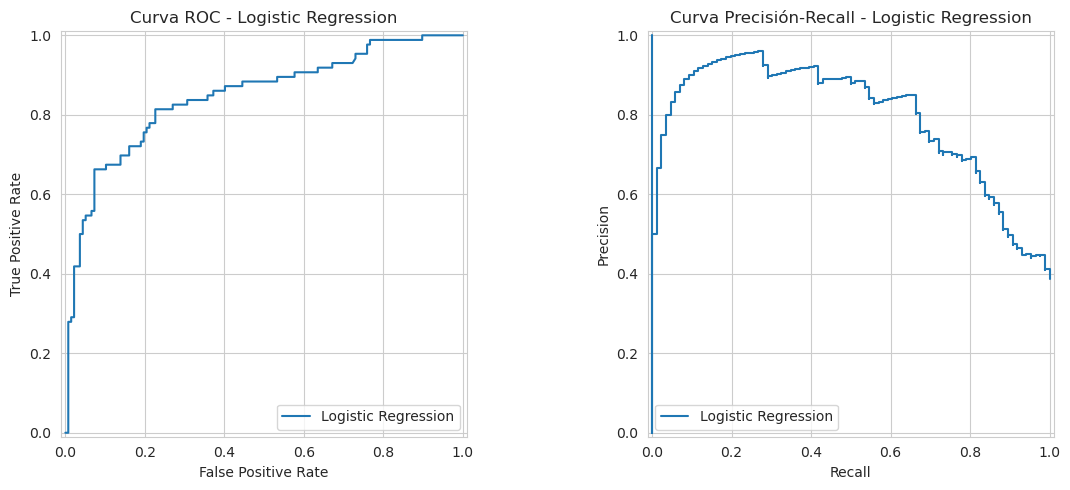

In [56]:
from sklearn.metrics import roc_curve, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
probs_best = best_model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, probs_best)
precision, recall, _ = precision_recall_curve(y_val, probs_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=best_model_name).plot(ax=axes[0])
axes[0].set_title('Curva ROC - ' + best_model_name)
PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name=best_model_name).plot(ax=axes[1])
axes[1].set_title('Curva Precisión-Recall - ' + best_model_name)
plt.tight_layout()
plt.show()


### Optimización del mejor modelo
Ajustamos hiperparámetros del modelo ganador con `RandomizedSearchCV` sobre `roc_auc`.

In [57]:
from sklearn.model_selection import RandomizedSearchCV
param_spaces = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 3, 5, 8],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 4, 6]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs','saga']
    }
}
search_estimator = fitted_models[best_model_name]
param_grid = param_spaces.get(best_model_name, {})

if param_grid:
    random_search = RandomizedSearchCV(search_estimator, param_grid, n_iter=10, scoring='roc_auc', cv=3, random_state=0, n_jobs=-1)
    random_search.fit(X_train, y_train)
    tuned_model = random_search.best_estimator_
    print('Mejores parámetros:', random_search.best_params_)
else:
    tuned_model = search_estimator
    print('No se encontraron parámetros para ajustar en', best_model_name)


/home/jmsa/miniforge3/envs/pia-ud1/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/jmsa/miniforge3/envs/pia-ud1/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/jmsa/miniforge3/envs/pia-ud1/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/jmsa/miniforge3/en

Mejores parámetros: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}


### Guardado del modelo final
Salvamos el modelo con los mejores hiperparámetros para usarlo en deploy o scoring reproducible.

In [58]:
joblib.dump(tuned_model, 'outputs/modelo_final.joblib')
print('Modelo final guardado en outputs/modelo_final.joblib')


Modelo final guardado en outputs/modelo_final.joblib


In [1]:
# Classification Functional API Example

# loading sample dataset
from pycaret.datasets import get_data
data = get_data('juice')

# init setup
from pycaret.classification import *
s = setup(data, target = 'Purchase', session_id = 123)

# model training and selection
best = compare_models()

# evaluate trained model
evaluate_model(best)

# predict on hold-out/test set
pred_holdout = predict_model(best)

# predict on new data
new_data = data.copy().drop('Purchase', axis = 1)
predictions = predict_model(best, data = new_data)

# save model
save_model(best, 'best_pipeline')

,Id,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,1,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,2,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,3,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,4,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,5,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


,Description,Value
0,Session id,123
1,Target,Purchase
2,Target type,Binary
3,Target mapping,"CH: 0, MM: 1"
4,Original data shape,"(1070, 19)"
5,Transformed data shape,"(1070, 19)"
6,Transformed train set shape,"(749, 19)"
7,Transformed test set shape,"(321, 19)"
8,Numeric features,17
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.8278,0.8941,0.8278,0.8299,0.8268,0.6354,0.6388,0.0820
lr,Logistic Regression,0.8184,0.8930,0.8184,0.8197,0.8163,0.6121,0.6164,0.8450
ridge,Ridge Classifier,0.8158,0.8938,0.8158,0.8183,0.8146,0.6099,0.6138,0.0980
gbc,Gradient Boosting Classifier,0.8037,0.8888,0.8037,0.8086,0.8031,0.5877,0.5926,0.2170
lightgbm,Light Gradient Boosting Machine,0.7930,0.8729,0.7930,0.7946,0.7925,0.5636,0.5658,26.8840
ada,Ada Boost Classifier,0.7917,0.8640,0.7917,0.7917,0.7899,0.5565,0.5592,0.1910
rf,Random Forest Classifier,0.7797,0.8724,0.7797,0.7819,0.7789,0.5355,0.5384,0.2290
et,Extra Trees Classifier,0.7678,0.8479,0.7678,0.7685,0.7669,0.5097,0.5114,0.2740
dt,Decision Tree Classifier,0.7650,0.7582,0.7650,0.7696,0.7657,0.5107,0.5131,0.0760
nb,Naive Bayes,0.7571,0.8208,0.7571,0.7649,0.7584,0.4985,0.5020,0.0930


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.8380,0.9073,0.8380,0.8371,0.8372,0.6564,0.6569


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Id', 'WeekofPurchase', 'StoreID',
                                              'PriceCH', 'PriceMM', 'DiscCH',
                                              'DiscMM', 'SpecialCH', 'SpecialMM',
                                              'LoyalCH', 'SalePriceMM',
                                              'SalePriceCH', 'PriceDi...
                                                                drop_invariant=False,
                                                                handle_missing='return_nan',
                                                                handle_unknown='value',
                           